<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Stepwise-Regression/Stepwise_Regression_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stepwise Regression-Scratch

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.datasets import load_iris

# 1. Load the dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Add the Intercept (Constant)
# Statsmodels requires this explicitly to calculate the p-values for 'b'
X = sm.add_constant(X)

Data Processing

In [ ]:
def backward_elimination(X, y, threshold=0.05):
    features = X.columns.tolist()
    while len(features) > 0:
        model = sm.OLS(y, X[features]).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p > threshold:
            feature_to_remove = p_values.idxmax()
            features.remove(feature_to_remove)
            print(f"Backward: Removing {feature_to_remove} (P={max_p:.4f})")
        else:
            break
    return features

In [ ]:
def forward_selection(X, y, threshold=0.05):
    initial_features = X.columns.tolist()
    best_features = []
    while len(initial_features) > 0:
        remaining_features = list(set(initial_features) - set(best_features))
        new_p_values = pd.Series(index=remaining_features, dtype='float64')

        for feature in remaining_features:
            model = sm.OLS(y, X[best_features + [feature]]).fit()
            new_p_values[feature] = model.pvalues[feature]

        min_p = new_p_values.min()
        if min_p < threshold:
            best_feature = new_p_values.idxmin()
            best_features.append(best_feature)
            print(f"Forward: Adding {best_feature} (P={min_p:.4f})")
        else:
            break
    return best_features

In [ ]:
def bidirectional_selection(X, y, sl_enter=0.05, sl_remove=0.05):
    features = []
    available_features = X.columns.tolist()

    while True:
        # 1. Forward Step
        changed = False
        remaining = list(set(available_features) - set(features))
        new_p = pd.Series(index=remaining, dtype='float64')
        for feature in remaining:
            new_p[feature] = sm.OLS(y, X[features + [feature]]).fit().pvalues[feature]

        if new_p.min() < sl_enter:
            best_feature = new_p.idxmin()
            features.append(best_feature)
            changed = True
            print(f"Stepwise: Added {best_feature}")

        # 2. Backward Step
        model = sm.OLS(y, X[features]).fit()
        p_values = model.pvalues.iloc[1:] # ignore constant
        if p_values.max() > sl_remove:
            worst_feature = p_values.idxmax()
            features.remove(worst_feature)
            changed = True
            print(f"Stepwise: Removed {worst_feature}")

        if not changed: break
    return features

In [ ]:
# Assuming the functions from the previous step are defined
print("--- Training: Stepwise Models ---")

# Execute Search Strategies
back_features = backward_elimination(X, y)
forw_features = forward_selection(X, y)
step_features = bidirectional_selection(X, y)

# Train the Final "Best" Model (using Stepwise results)
# OLS (Ordinary Least Squares) is the training engine here
final_model = sm.OLS(y, X[step_features]).fit()

print("\nTraining Complete.")
print(f"Features Selected: {step_features}")

--- Training: Stepwise Models ---
Backward: Removing sepal width (cm) (P=0.5030)
Backward: Removing const (P=0.4588)
Forward: Adding petal width (cm) (P=0.0000)
Forward: Adding sepal width (cm) (P=0.0000)
Forward: Adding petal length (cm) (P=0.0000)
Stepwise: Added petal width (cm)
Stepwise: Added sepal width (cm)
Stepwise: Added petal length (cm)

Training Complete.
Features Selected: ['petal width (cm)', 'sepal width (cm)', 'petal length (cm)']


Implementation And Training

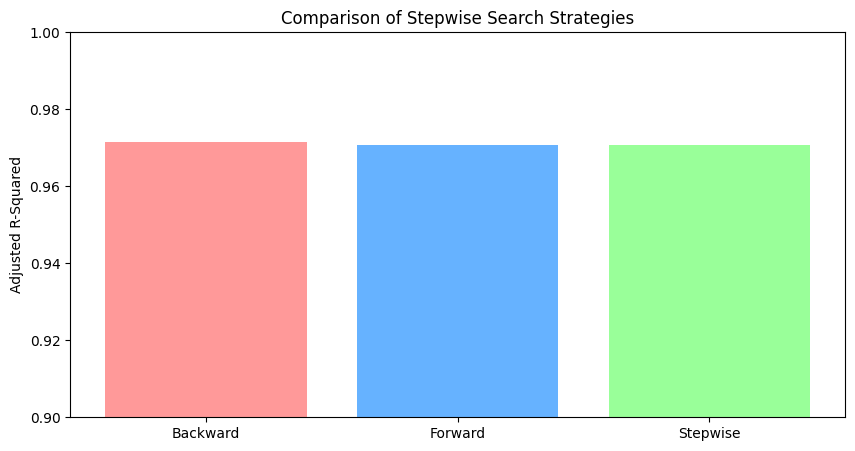

In [ ]:
import matplotlib.pyplot as plt

# Visualization: Compare Adjusted R-Squared of the 3 approaches
results = {
    "Backward": sm.OLS(y, X[back_features]).fit().rsquared_adj,
    "Forward": sm.OLS(y, X[forw_features]).fit().rsquared_adj,
    "Stepwise": sm.OLS(y, X[step_features]).fit().rsquared_adj
}

plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['#FF9999', '#66B2FF', '#99FF99'])
plt.ylim(0.9, 1.0) # Zoom in to see small differences
plt.ylabel('Adjusted R-Squared')
plt.title('Comparison of Stepwise Search Strategies')
plt.show()

Visualization

In Stepwise Regression, we transitioned from using mathematical penalties (like Ridge or Lasso) to using statistical search strategies for feature selection. By implementing Forward Selection, we built the model from the ground up, adding only the most significant contributors; with Backward Elimination, we started with the full feature set and systematically "pruned" the variables that failed to meet our p-value significance threshold. The Bi-directional (Stepwise) approach acted as a sophisticated hybrid, constantly re-evaluating previously added features to ensure they hadn't become redundant as new data entered the equation. Ultimately, this process allowed us to move beyond simple curve-fitting to create a parsimonious model—one that achieves maximum predictive power using the minimum necessary number of variables, ensuring the final output is both statistically sound and computationally efficient.